In [29]:
import pandas as pd
import matplotlib.pyplot as plt

In [30]:
df = pd.read_csv("../files/embalses_mes.csv")

In [31]:
df['FECHA'] = pd.to_datetime(df['FECHA'])

In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7331 entries, 0 to 7330
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   AMBITO_NOMBRE     7331 non-null   str           
 1   FECHA             7331 non-null   datetime64[us]
 2   PORCENTAJE_LLENO  7329 non-null   float64       
 3   CATEGORIA         7331 non-null   str           
dtypes: datetime64[us](1), float64(1), str(2)
memory usage: 229.2 KB


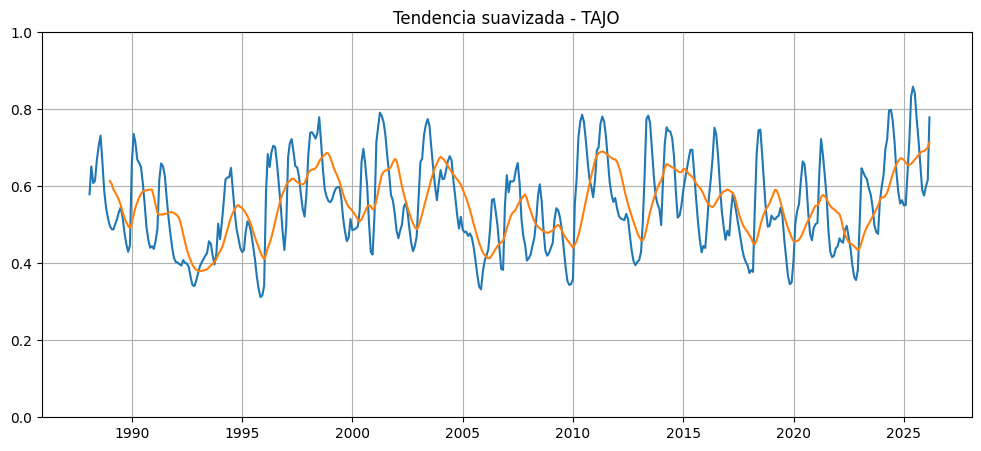

In [33]:
cuenca = "TAJO"

df_plot = df[df["AMBITO_NOMBRE"] == cuenca]

plt.figure(figsize=(12,5))
plt.plot(df_plot["FECHA"], df_plot["PORCENTAJE_LLENO"])

# media móvil 12 meses
plt.plot(
    df_plot["FECHA"],
    df_plot["PORCENTAJE_LLENO"].rolling(12).mean(),
)

plt.title(f"Tendencia suavizada - {cuenca}")
plt.ylim(0,1)
plt.grid(True)
plt.show()

In [34]:
df_volatilidad = (
    df
    .groupby("AMBITO_NOMBRE")["PORCENTAJE_LLENO"]
    .std()
    .sort_values(ascending=False)
)

df_volatilidad

AMBITO_NOMBRE
GUADALETE-BARBATE                  0.234872
GUADALQUIVIR                       0.223140
GUADIANA                           0.212452
CUENCAS INTERNAS DE CATALUÑA       0.208455
SEGURA                             0.164224
CUENCA MEDITERRÁNEA ANDALUZA       0.162649
DUERO                              0.153082
TINTO, ODIEL Y PIEDRAS             0.144724
CANTÁBRICO ORIENTAL                0.140138
JÚCAR                              0.138779
GALICIA COSTA                      0.135009
MIÑO - SIL                         0.134894
CUENCAS INTERNAS DEL PAÍS VASCO    0.134047
EBRO                               0.128737
TAJO                               0.118958
CANTÁBRICO OCCIDENTAL              0.117758
Name: PORCENTAJE_LLENO, dtype: float64

Mayor desviación estándar = más vulnerable a sequías bruscas

In [35]:
df_minimos = (
    df
    .groupby("AMBITO_NOMBRE")["PORCENTAJE_LLENO"]
    .min()
    .sort_values()
)

df_minimos

AMBITO_NOMBRE
GUADALETE-BARBATE                  0.020934
TAJO                               0.062500
SEGURA                             0.072356
JÚCAR                              0.073823
GUADIANA                           0.090856
GUADALQUIVIR                       0.094356
CUENCA MEDITERRÁNEA ANDALUZA       0.102650
CUENCAS INTERNAS DE CATALUÑA       0.149557
CANTÁBRICO ORIENTAL                0.181818
DUERO                              0.296190
TINTO, ODIEL Y PIEDRAS             0.311828
GALICIA COSTA                      0.328216
MIÑO - SIL                         0.330099
EBRO                               0.352371
CANTÁBRICO OCCIDENTAL              0.386157
CUENCAS INTERNAS DEL PAÍS VASCO    0.438095
Name: PORCENTAJE_LLENO, dtype: float64

qué cuencas han tenido peores mínimos históricos

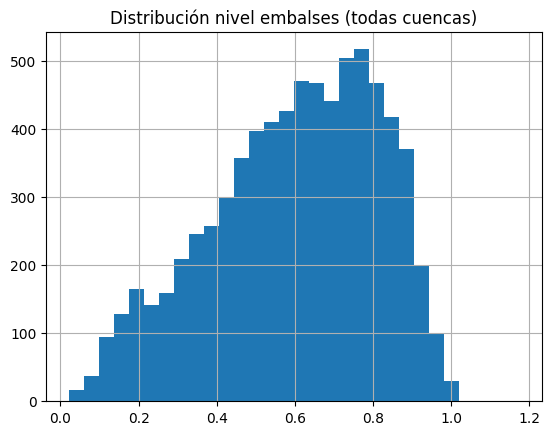

In [36]:
df["PORCENTAJE_LLENO"].hist(bins=30)
plt.title("Distribución nivel embalses (todas cuencas)")
plt.show()

la distribución tiene cola a la izquierda
- La mayoría del tiempo las cuencas están bastante llenas
- Pcasionalmente ocurren sequías severas
- Esos episodios son extremos pero poco frecuentes

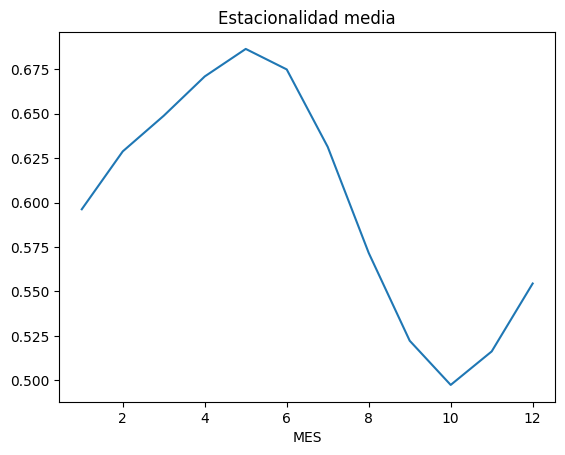

In [37]:
df["MES"] = df["FECHA"].dt.month

df_estacionalidad = (
    df
    .groupby("MES")["PORCENTAJE_LLENO"]
    .mean()
)

df_estacionalidad.plot()
plt.title("Estacionalidad media")
plt.show()

se observa una estacionalidad fuerte

In [38]:
df["SEQUIA"] = df["PORCENTAJE_LLENO"] < 0.4

df_sequia_freq = (
    df
    .groupby("AMBITO_NOMBRE")["SEQUIA"]
    .mean()
    .sort_values(ascending=False)
)

df_sequia_freq

AMBITO_NOMBRE
SEGURA                             0.788210
JÚCAR                              0.556769
GUADALQUIVIR                       0.382096
CUENCA MEDITERRÁNEA ANDALUZA       0.331878
GUADALETE-BARBATE                  0.301310
GUADIANA                           0.281659
CUENCAS INTERNAS DE CATALUÑA       0.187773
TAJO                               0.086768
DUERO                              0.056769
TINTO, ODIEL Y PIEDRAS             0.026201
EBRO                               0.024017
CANTÁBRICO ORIENTAL                0.019651
GALICIA COSTA                      0.015284
MIÑO - SIL                         0.013100
CANTÁBRICO OCCIDENTAL              0.002183
CUENCAS INTERNAS DEL PAÍS VASCO    0.000000
Name: SEQUIA, dtype: float64

La cuenca con más sequías es la del segura, estando el 78% del iempo por debajo de 40% de su capacidad

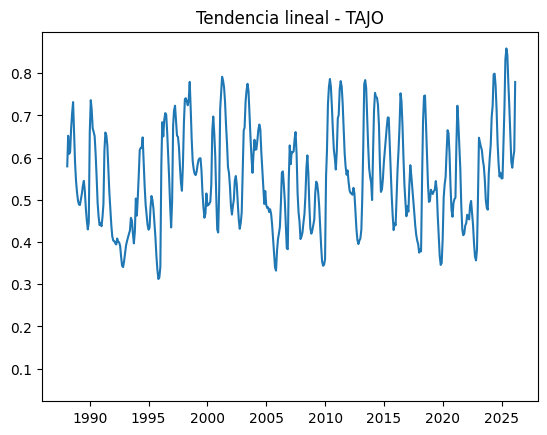

In [39]:
import numpy as np

df_plot = df[df["AMBITO_NOMBRE"] == cuenca]

x = np.arange(len(df_plot))
y = df_plot["PORCENTAJE_LLENO"].values

coef = np.polyfit(x, y, 1)
tendencia = np.poly1d(coef)

plt.plot(df_plot["FECHA"], y)
plt.plot(df_plot["FECHA"], tendencia(x))
plt.title(f"Tendencia lineal - {cuenca}")
plt.show()

## Detectar períodos de sequía prolongada

In [40]:
# Definir sequía (umbral)
df = df.sort_values(["AMBITO_NOMBRE","FECHA"]).copy()
df["SEQUIA"] = df["PORCENTAJE_LLENO"] < 0.4

In [41]:
# Identificar rachas consecutivas de sequía
df["grp"] = (
    df
    .groupby("AMBITO_NOMBRE")["SEQUIA"]
    .apply(lambda s: (s != s.shift()).cumsum())
    .reset_index(level=0, drop=True)
)

In [42]:
# Resumir cada racha
rachas = (
    df[df["SEQUIA"]]
    .groupby(["AMBITO_NOMBRE","grp"])
    .agg(
        inicio=("FECHA","min"),
        fin=("FECHA","max"),
        duracion_meses=("FECHA","count"),
        min_lleno=("PORCENTAJE_LLENO","min"),
        media_lleno=("PORCENTAJE_LLENO","mean")
    )
    .reset_index()
)

rachas.head()

,AMBITO_NOMBRE,grp,inicio,fin,duracion_meses,min_lleno,media_lleno
0,CANTÁBRICO OCCIDENTAL,2,1999-09-30,1999-09-30,1,0.386157,0.386157
1,CANTÁBRICO ORIENTAL,2,1989-10-31,1990-04-30,7,0.181818,0.248810
2,CANTÁBRICO ORIENTAL,4,1995-12-31,1996-01-31,2,0.369014,0.381690
3,CUENCA MEDITERRÁNEA ANDALUZA,2,1988-09-30,1989-01-31,5,0.356645,0.373174
4,CUENCA MEDITERRÁNEA ANDALUZA,4,1989-10-31,1989-10-31,1,0.387613,0.387613


In [43]:
# Filtrar sequías prolongadas
sequias_largas = rachas[rachas["duracion_meses"] >= 6].sort_values(
    ["duracion_meses","min_lleno"], ascending=[False, True]
)

sequias_largas.head(10)

,AMBITO_NOMBRE,grp,inicio,fin,duracion_meses,min_lleno,media_lleno
93,SEGURA,3,1998-08-31,2010-01-31,138,0.093888,0.199668
92,SEGURA,1,1988-01-31,1998-01-31,121,0.072356,0.194092
82,JÚCAR,9,1998-09-30,2004-04-30,68,0.115660,0.264234
83,JÚCAR,11,2004-08-31,2010-01-31,66,0.118530,0.250482
72,GUADIANA,8,1991-06-30,1996-01-31,56,0.090856,0.177730
80,JÚCAR,5,1992-07-31,1997-01-31,55,0.073823,0.202344
56,GUADALQUIVIR,6,1991-07-31,1996-01-31,55,0.094356,0.192615
95,SEGURA,7,2016-05-31,2020-03-31,47,0.132778,0.265314
53,GUADALETE-BARBATE,16,2021-07-31,2025-02-28,44,0.144882,0.262680
47,GUADALETE-BARBATE,4,1992-07-31,1996-01-31,43,0.020934,0.123812


In [44]:
ranking = (
    sequias_largas
    .groupby("AMBITO_NOMBRE")
    .agg(
        n_sequias=("duracion_meses","count"),
        duracion_media=("duracion_meses","mean"),
        peor_min=("min_lleno","min")
    )
    .sort_values(["duracion_media","peor_min"], ascending=[False, True])
)

ranking

,n_sequias,duracion_media,peor_min
AMBITO_NOMBRE,,,
SEGURA,5,71.200000,0.072356
JÚCAR,6,39.833333,0.073823
GUADALETE-BARBATE,4,30.250000,0.020934
GUADIANA,6,20.000000,0.090856
CUENCA MEDITERRÁNEA ANDALUZA,7,18.428571,0.102650
GUADALQUIVIR,10,15.400000,0.094356
CUENCAS INTERNAS DE CATALUÑA,5,14.200000,0.149557
TAJO,1,8.000000,0.340609
CANTÁBRICO ORIENTAL,1,7.000000,0.181818


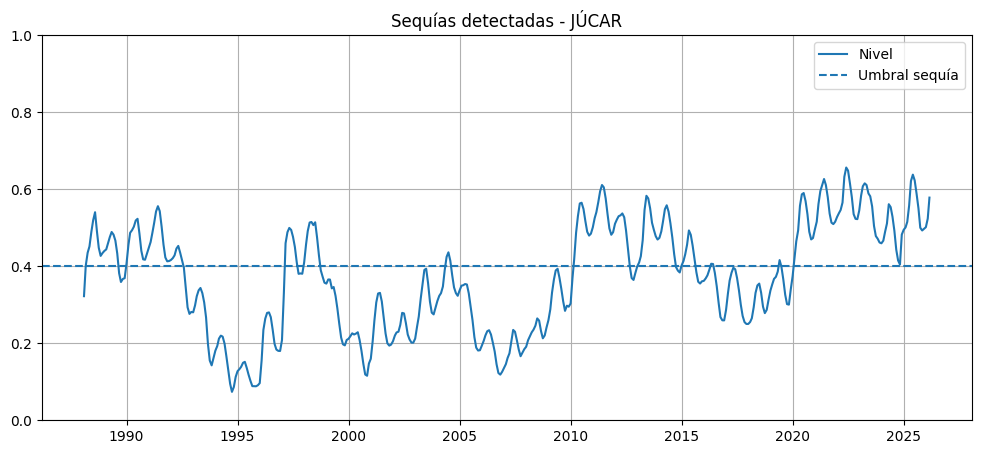

In [48]:
cuenca = "JÚCAR"

df_plot = df[df["AMBITO_NOMBRE"] == cuenca]

plt.figure(figsize=(12,5))
plt.plot(df_plot["FECHA"], df_plot["PORCENTAJE_LLENO"], label="Nivel")

plt.axhline(0.4, linestyle="--", label="Umbral sequía")

plt.title(f"Sequías detectadas - {cuenca}")
plt.ylim(0,1)
plt.legend()
plt.grid(True)
plt.show()